In [1]:
# %% [markdown]
# ## MPC-Control Simulation and Data Analysis (CcaS/CcaR TCS)

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit
import warnings
warnings.filterwarnings("ignore")

from model_and_controller_equations.run_all_controllers import run_control
from model_and_controller_equations.run_constant import run_constant
from signal_analysis import analyze_signal

In [2]:
# %%
# Load experimental fluorescence datasets
data1 = pd.read_csv('experiment_data/P-FL_OD_run_data_042325.csv')
data2 = pd.read_csv('experiment_data/P-FL_OD_run_data_040625.csv')

# Extract experimental replicates
P1_data1 = data1[['SP1_1', 'SP1_2', 'SP1_3', 'SP1_4', 'SP1_5', 'SP1_6']].to_numpy()
P2_data1 = data1[['SP2_1', 'SP2_2', 'SP2_3', 'SP2_4', 'SP2_5', 'SP2_6']].to_numpy()

P1_data2 = data2[['SP1_1', 'SP1_2', 'SP1_3']].to_numpy()
P2_data2 = data2[['SP2_1', 'SP2_2', 'SP2_3']].to_numpy()

green_data1 = data1[['G1']].to_numpy()
green_data2 = data2[['G1', 'G2', 'G3']].to_numpy()
red_data1 = data1[['R1']].to_numpy()
red_data2 = data2[['R1', 'R2', 'R3']].to_numpy()

# Truncate all data to shared minimum length
min_len = min(P1_data1.shape[0], P1_data2.shape[0])
P1_data1 = P1_data1[:min_len]; P2_data1 = P2_data1[:min_len]
P1_data2 = P1_data2[:min_len]; P2_data2 = P2_data2[:min_len]
green_data1 = green_data1[:min_len]; green_data2 = green_data2[:min_len]
red_data1 = red_data1[:min_len]; red_data2 = red_data2[:min_len]


In [3]:
# %%
# Merge all experimental replicates
P1_all = np.hstack((P1_data1, P1_data2))
P2_all = np.hstack((P2_data1, P2_data2))
green_all = np.hstack((green_data1, green_data2))
red_all = np.hstack((red_data1, red_data2))

# Compute means and standard deviations
P1_mean = np.mean(P1_all, axis=1)
P1_std = np.std(P1_all, axis=1)
P2_mean = np.mean(P2_all, axis=1)
P2_std = np.std(P2_all, axis=1)
green_mean = np.mean(green_all, axis=1)
green_std = np.std(green_all, axis=1)
red_mean = np.mean(red_all, axis=1)
red_std = np.std(red_all, axis=1)


In [4]:
# %%
# Time parameters
interval = 10
time_exp = np.arange(interval, (min_len + 1) * interval, interval)
t_final = 16 * 60

# Setpoints from experiments
st_pt_1 = 11500
st_pt_2 = 18500

# Normalize scale using green max
green_max = np.max(green_mean)

# Color dictionary
color_dict = {
    'set_point_1': '#6759d4',
    'set_point_2': '#ebab4b',
    'green': 'green',
    'red': 'red',
    'PID': 'black',
    'PID-GS': '#1f78b4', 
    'FF': '#dd3497',
    'PID-FF': '#fc8d62',
    'PID-GS-FF': '#03cea4'
}

# Normalize experimental data
P1_mean_norm = P1_mean / green_max
P1_std_norm = P1_std / green_max
P2_mean_norm = P2_mean / green_max
P2_std_norm = P2_std / green_max
green_mean_norm = green_mean / green_max
green_std_norm = green_std / green_max
red_mean_norm = red_mean / green_max
red_std_norm = red_std / green_max


In [5]:
# define model parameters 


p = pd.read_csv('parameters/TCS_params_guess_070225.csv').to_numpy()

p = p[:,2]

params = lmfit.Parameters()

params.add(name = 'k_green', value = p[0], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_red', value = p[1], min = 1e0, max = 1e4, vary = 1)
params.add(name = 'b_green', value = p[2], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'b_red', value = p[3], min = 1e0, max = 1e4, vary = 1)

params.add(name = 'k_sp_b', value = p[4], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_sp_u', value = p[5], min = 1e-4, max = 1e4, vary = 1)

params.add(name = 'k_rp_b', value = p[6], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_rp_u', value = p[7], min = 1e-4, max = 1e4, vary = 1)

params.add(name = 'beta', value = p[8], min = 1e-1, max = 500, vary = 1)
params.add(name = 'l0', value = p[9], min = 0, max = 0.5, vary = 1)
params.add(name = 'Kc', value = p[10], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'd_m', value = p[11], min = 0.05, max = 0.35, vary = 1)
params.add(name = 'k_tl', value = p[12], min = 0.05, max = 10, vary = 1)
params.add(name = 'k_tli_b', value = p[13], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_tli_u', value = p[14], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'd_p', value = p[15], min = 1e-6, max = 1e-1, vary = 1)
params.add(name = 'k_fold', value = p[16], min = 0.05, max = 0.3, vary = 1)
params.add(name = 'b_fold', value = p[17], min = 0.1, max = 2, vary = 1)
params.add(name = 'n_gamma', value = p[18], min = 0.05, max = 0.9, vary = 1)
params.add(name = 'R_max', value = p[19], min = 1e0, max = 1e4, vary = 1)

params.add(name = 'S_0', value = p[20], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'R_0', value = p[21], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Sp_0', value = p[22], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Rp_0', value = p[23], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'mRNA_0', value = p[24], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'P_0', value = p[25], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Pm_0', value = p[26], min = 1e-4, max = 1e4, vary = 1)


params.add(name = 'k_gr', value = p[27], vary = 0)
params.add(name = 'C_max', value = p[28], vary = 0)
params.add(name = 'C_0', value = p[29], vary = 0)

params.add(name = 'n_tcs', value = p[30], min = 0.1, max = 5, vary = 1)

# define initial conditions and solve the ODEs

x0 = np.zeros(11)

x0[0] = p[20] # S
x0[1] = p[22]# Sp
x0[2] = p[21] # R
x0[3] = p[23] # Rp
x0[4] = 0 # Ac
x0[5] = p[24] # mRNA
x0[6] = 0 # Ctic
x0[7] = p[25] # Unfolded Protein 
x0[8] = p[26] # Folded Protein 
x0[9] = p[29] # Initial Cell count
x0[10] = 0 # Initial Integral Error

t_final = 960

In [6]:
# Simulate constant inputs (open loop) without any disturbance for baseline measurement

time_green_no_perturbn, _, sol_green_no_perturbn = run_constant(t_final, x0, params, constant_input = 'green', growth_perturb=0)
time_red_no_perturbn, _, sol_red_no_perturbn = run_constant(t_final, x0, params, constant_input = 'red', growth_perturb=0)
time_dark_no_perturbn, _, sol_dark_no_perturbn = run_constant(t_final, x0, params, constant_input = 'dark', growth_perturb=0)

st_pt_1_model = st_pt_1 * (np.max(sol_green_no_perturbn[:,8]))/green_max
st_pt_2_model = st_pt_2 * (np.max(sol_green_no_perturbn[:,8]))/green_max

### Simulation of different controller stratgeies for disturbance rejection

In [7]:
# Controller parameters

# simulate the pre-run step
def closest_index(timepoints, target):
    tp = np.asarray(timepoints)
    i = np.searchsorted(tp, target, side="left")
    if i == 0:
        return 0
    if i == len(tp):
        return len(tp) - 1
    return i-1 if (target - tp[i-1]) <= (tp[i] - target) else i

t_rerun = 100
i_rerun = closest_index(time_green_no_perturbn, t_rerun)
x0 = sol_green_no_perturbn[i_rerun, :]


scaling_factor = (green_max/(np.max(sol_green_no_perturbn[:,8]))) * (1/60)

pid_gain = 0.032 * scaling_factor
FF_gain = 0.8 * scaling_factor
PID_FF_gain = 0.8 * scaling_factor

tolerence_percentage = 0.05 # 10%


# perturbation parameters
perturb_percent = 40 # If the sample is diluted by X%, the final OD equals the original (pre-dilution) OD multiplied by (100 − X)/100.
perturb_time = 480 # perturbation happens at this time
new_t_final = 16*60 # new experiment end time after perturbation


# Simulate constant inputs (open loop)
time_green_with_perturbn, _, sol_green_with_perturbn = run_constant(t_final, x0, params, constant_input = 'green', growth_perturb=1,
                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                 new_t_final=new_t_final)

time_red_with_perturbn, _, sol_red_with_perturbn = run_constant(t_final, x0, params, constant_input = 'red', growth_perturb=1,
                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                 new_t_final=new_t_final)

open_loop_duty_cycle = 3.8 #%
t_SP2_open_loop, _, sol_SP2_open_loop = run_constant(t_final, x0, params, constant_input = 'green', growth_perturb=1,
                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                 new_t_final=new_t_final, duty_cycle=open_loop_duty_cycle)

# Simulate disturbance rejection using plain PID, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID, ctrl_SP2_PID_to_PID, sol_SP2_PID_to_PID, t_green_on_SP2_PID_to_PID,  opt_times_SP2_PID_to_PID = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID",
                                                                print_perturb_message=True)

Perturbing now
Perturbation applied at time 480 to bring to 172.94392523364485 minutes
Perturbing now
Perturbation applied at time 480 to bring to 172.94392523364485 minutes
Perturbing now
Perturbation applied at time 480.0 to bring to 172.97388679245284 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 172.93812817363752 minutes


In [8]:
# Normalize simulation and experimental outputs
green_sim_norm = sol_green_with_perturbn[:,8] / np.max(sol_green_no_perturbn[:,8])
red_sim_norm = sol_red_with_perturbn[:,8] / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_norm = np.array(ctrl_SP2_PID_to_PID) / np.max(sol_green_no_perturbn[:,8])
sol_SP2_open_loop_norm = sol_SP2_open_loop[:,8] / np.max(sol_green_no_perturbn[:,8])

dynamic_range_norm = np.max(sol_green_no_perturbn[:,8] - sol_red_no_perturbn[:,8])  / np.max(sol_green_no_perturbn[:,8])

time_extent = min((max(time_green_with_perturbn), max(time_red_with_perturbn), max(t_SP2_PID_to_PID)))

# extract growth profiles 
growth_green_with_perturbn = sol_green_with_perturbn[:,9] 
growth_red_with_perturbn = sol_red_with_perturbn[:,9] 

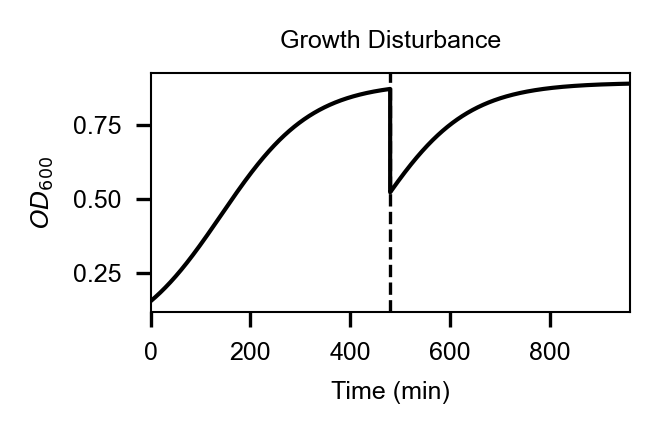

In [9]:
# %%
# Plot the growth perturbation
# Styling matched to PID disturbance-response plots

growth_plot_cfg = {
    'figsize': (2.25, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'line_width': 1,
    'axis_linewidth': 0.5,
    'perturb_linewidth': 0.8,
}

plt.rcParams.update({
    'font.family': growth_plot_cfg['font_family'],
    'font.size': growth_plot_cfg['base_fontsize'],
    'axes.labelsize': growth_plot_cfg['label_fontsize'],
    'axes.titlesize': growth_plot_cfg['title_fontsize'],
    'legend.fontsize': growth_plot_cfg['legend_fontsize']
})

fig, ax = plt.subplots(figsize=growth_plot_cfg['figsize'], dpi=growth_plot_cfg['dpi'])

# Growth profiles
ax.plot(time_green_with_perturbn, growth_green_with_perturbn / 8e8, color='black', linewidth=growth_plot_cfg['line_width'])

# Perturbation marker
ax.axvline(perturb_time, color='black', linestyle='--', linewidth=growth_plot_cfg['perturb_linewidth'])

# Labels and limits
ax.set_xlabel('Time (min)', fontsize=growth_plot_cfg['label_fontsize'])

ax.set_ylabel(r'$OD_{600}$', fontsize=growth_plot_cfg['label_fontsize'])

# ax.set_title(f'{perturb_percent}% Perturbation', fontsize=growth_plot_cfg['title_fontsize'])
ax.set_title('Growth Disturbance', fontsize=growth_plot_cfg['title_fontsize'])

ax.set_xlim(0, time_extent)

# Match PID plot axis styling
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(
        growth_plot_cfg['axis_linewidth']
    )

ax.tick_params(
    axis='both',
    which='major',
    labelsize=growth_plot_cfg['tick_fontsize']
)

# plt.tight_layout()
# Fixed axes position so plot boxes align across figures
fig.subplots_adjust(
    left=0.25,
    right=0.96,
    bottom=0.25,
    top=0.82
)

plt.savefig(
    'figures/growth_disturbance.svg',
    format='svg',
    dpi=300,
    #bbox_inches='tight',
    transparent=True
)

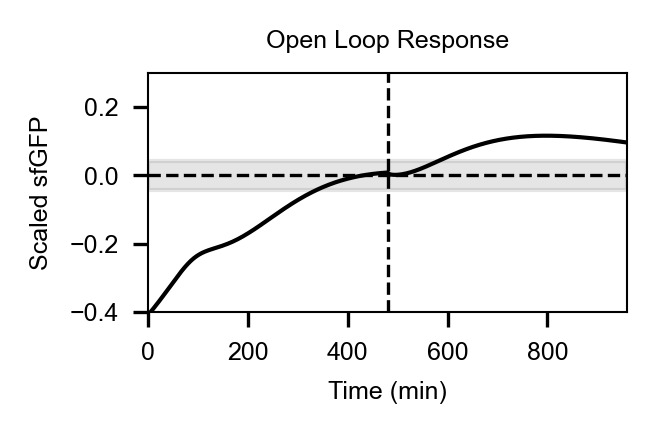

In [10]:
# %%
# Plot normalized green simulation
# Styling matched to PID disturbance-response plots

green_plot_cfg = {
    'figsize': (2.25, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'line_width': 1,
    'axis_linewidth': 0.5,
    'perturb_linewidth': 0.8,
    'legend_loc': 'lower right'
}

plt.rcParams.update({
    'font.family': green_plot_cfg['font_family'],
    'font.size': green_plot_cfg['base_fontsize'],
    'axes.labelsize': green_plot_cfg['label_fontsize'],
    'axes.titlesize': green_plot_cfg['title_fontsize'],
    'legend.fontsize': green_plot_cfg['legend_fontsize']
})

fig, ax = plt.subplots(
    figsize=green_plot_cfg['figsize'],
    dpi=green_plot_cfg['dpi']
)

# Normalized green simulation
# ax.plot(
#     time_green_with_perturbn,
#     green_sim_norm,
#     color=color_dict['green'],
#     linewidth=green_plot_cfg['line_width'],
#     label='Const. Green'
# )

# ax.plot(
#     time_red_with_perturbn,
#     red_sim_norm,
#     color=color_dict['red'],
#     linewidth=green_plot_cfg['line_width'],
#     label='Const. Red'
# )

# setpoint norm:
set_point_2_norm = st_pt_2_model / np.max(sol_green_no_perturbn[:,8])

#tolerence band
dynamic_range_norm = np.max(sol_green_no_perturbn[:, 8] - sol_red_no_perturbn[:, 8]) / np.max(sol_green_no_perturbn[:,8])
tol_band_norm = dynamic_range_norm * tolerence_percentage

ax.plot(
    t_SP2_open_loop,
    sol_SP2_open_loop_norm - set_point_2_norm,
    color='k',
    linewidth=green_plot_cfg['line_width'],
    label='Const. Duty Cycle')

# Perturbation marker
ax.axvline(
    perturb_time,
    color='black',
    linestyle='--',
    linewidth=green_plot_cfg['perturb_linewidth']
)

# Zero-error line and tolerance band
ax.axhline(set_point_2_norm - set_point_2_norm, color='k', linestyle='--', linewidth=green_plot_cfg['perturb_linewidth'])
ax.fill_between(
    [0, time_extent],
    tol_band_norm,
    -tol_band_norm,
    color='gray',
    alpha=0.2
)

# Labels and limits
ax.set_xlabel(
    'Time (min)',
    fontsize=green_plot_cfg['label_fontsize']
)

ax.set_ylabel(
    'Scaled sfGFP',
    fontsize=green_plot_cfg['label_fontsize']
)

# ax.set_title(f'{perturb_percent}% Perturbation', fontsize=green_plot_cfg['title_fontsize'])

ax.set_title('Open Loop Response', fontsize=green_plot_cfg['title_fontsize'])

ax.set_xlim(0, time_extent)
# ax.set_xlim(360, time_extent)
ax.set_ylim(-0.4, 0.3)

# ax.legend(frameon=False, loc=green_plot_cfg['legend_loc'], fontsize=green_plot_cfg['legend_fontsize'],
#           ncol=1, columnspacing=0.3, labelspacing=0.01, handlelength=0.5, handletextpad=0.3,
#           bbox_to_anchor=(1.05,0.4))
# ax.legend(frameon=False, loc=green_plot_cfg['legend_loc'], fontsize=green_plot_cfg['legend_fontsize'],
#           ncol=1, columnspacing=0.3, labelspacing=0.01, handlelength=0.5, handletextpad=0.3)

# Match PID plot axis styling
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(
        green_plot_cfg['axis_linewidth']
    )

ax.tick_params(
    axis='both',
    which='major',
    labelsize=green_plot_cfg['tick_fontsize']
)

# plt.tight_layout()
# Fixed axes position so plot boxes align across figures
fig.subplots_adjust(
    left=0.25,
    right=0.96,
    bottom=0.25,
    top=0.82
)

plt.savefig(
    'figures/open_loop_perturbation.svg',
    format='svg',
    dpi=300,
    #bbox_inches='tight',
    transparent=True
)

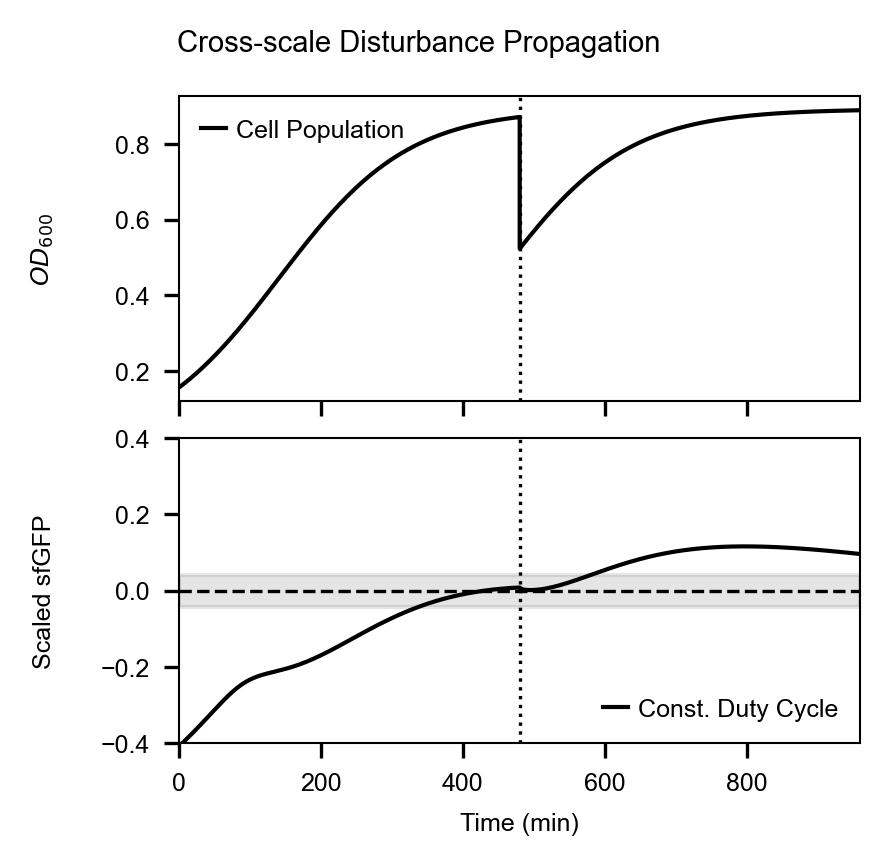

In [11]:
# ============================================================
# Combined figure: Growth + Open-loop disturbance propagation
# ============================================================

combined_plot_cfg = {
    'figsize': (3.2, 2.8),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 7,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'line_width': 1,
    'axis_linewidth': 0.5,
    'perturb_linewidth': 0.8
}

plt.rcParams.update({
    'font.family': combined_plot_cfg['font_family'],
    'font.size': combined_plot_cfg['base_fontsize'],
    'axes.labelsize': combined_plot_cfg['label_fontsize'],
    'axes.titlesize': combined_plot_cfg['title_fontsize'],
    'legend.fontsize': combined_plot_cfg['legend_fontsize']
})

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=combined_plot_cfg['figsize'],
    dpi=combined_plot_cfg['dpi'],
    sharex=True
)

# ============================================================
# Top subplot: Cell population
# ============================================================

ax1.plot(
    time_green_with_perturbn,
    growth_green_with_perturbn / 8e8,
    color='black',
    linewidth=combined_plot_cfg['line_width'],
    label='Cell Population'
)

ax1.set_ylabel(
    r'$OD_{600}$',
    fontsize=combined_plot_cfg['label_fontsize']
)

ax1.set_xlim(0, time_extent)

ax1.legend(
    frameon=False,
    loc='upper left',
    fontsize=combined_plot_cfg['legend_fontsize'],
    handlelength=1.0,
    handletextpad=0.4
)

# ============================================================
# Bottom subplot: Open-loop dynamics
# ============================================================

set_point_2_norm = (
    st_pt_2_model / np.max(sol_green_no_perturbn[:, 8])
)

dynamic_range_norm = (
    np.max(sol_green_no_perturbn[:, 8] - sol_red_no_perturbn[:, 8])
    / np.max(sol_green_no_perturbn[:, 8])
)

tol_band_norm = dynamic_range_norm * tolerence_percentage

ax2.plot(
    t_SP2_open_loop,
    sol_SP2_open_loop_norm - set_point_2_norm,
    color='black',
    linewidth=combined_plot_cfg['line_width'],
    label='Const. Duty Cycle'
)

ax2.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=combined_plot_cfg['perturb_linewidth']
)

ax2.fill_between(
    [0, time_extent],
    tol_band_norm,
    -tol_band_norm,
    color='gray',
    alpha=0.2
)

ax2.set_xlabel(
    'Time (min)',
    fontsize=combined_plot_cfg['label_fontsize']
)

ax2.set_ylabel(
    'Scaled sfGFP',
    fontsize=combined_plot_cfg['label_fontsize']
)

ax2.set_ylim(-0.4, 0.4)

ax2.legend(
    frameon=False,
    loc='lower right',
    fontsize=combined_plot_cfg['legend_fontsize'],
    handlelength=1.0,
    handletextpad=0.4
)

# ============================================================
# Common disturbance line
# ============================================================

for ax in (ax1, ax2):
    ax.axvline(
        perturb_time,
        color='black',
        linestyle=':',
        linewidth=combined_plot_cfg['perturb_linewidth'],
        zorder=10
    )

# ============================================================
# Axis styling
# ============================================================

for ax in (ax1, ax2):
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_linewidth(
            combined_plot_cfg['axis_linewidth']
        )

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=combined_plot_cfg['tick_fontsize']
    )

# ------------------------------------------------------------
# FORCE y-axis labels to align vertically
# ------------------------------------------------------------

ax1.yaxis.set_label_coords(-0.18, 0.5)
ax2.yaxis.set_label_coords(-0.18, 0.5)

# ============================================================
# Main title
# ============================================================

fig.suptitle(
    'Cross-scale Disturbance Propagation',
    fontsize=combined_plot_cfg['title_fontsize'],
    y=0.97
)

# ============================================================
# Fixed subplot geometry
# ============================================================

fig.subplots_adjust(
    left=0.25,
    right=0.96,
    bottom=0.12,
    top=0.89,
    hspace=0.12
)

plt.savefig(
    'figures/cross_scale_disturbance_propagation.svg',
    format='svg',
    dpi=300,
    transparent=True
)

plt.show()

In [12]:
def compute_performance_metric(ts_array, ITAE_array):
    """Computes a combined performance metric from settling times (ts) and ITAE.
    """
    ts = np.asarray(ts_array, dtype=float)
    itae = np.asarray(ITAE_array, dtype=float)

    if ts.shape != itae.shape:
        raise ValueError("ts_array and ITAE_array must have the same shape")
    
    min_perturb_time = 6 * 60 # the culture should grow for at least 6 hours before perturbation
     
    # itae max should be the integrated error if the system never settles within tolerence and we have a constant error equal to the tolerence band
    itae_max = tolerence_percentage * dynamic_range_norm * (new_t_final - min_perturb_time) * (new_t_final - min_perturb_time)/2
    ts_max = new_t_final - min_perturb_time
    # itae_max = 1e4
    # ts_max = 600

    ts_norm = ts/ts_max
    itae_norm = itae/itae_max

    metric = np.sqrt(ts_norm**2 + itae_norm**2)
    return metric

In [13]:
# %%
# PID-only variation analysis across disturbance magnitudes

# -------------------------------
# User settings
# -------------------------------
perturb_time_var = 480          # min
perturb_percents = [20, 40, 60, 80]
new_t_final_var = 16 * 60       # min

# Colors for disturbance percentages
# disturbance_colors = {
#     20: '#98d9ea',
#     40: '#6baed6',
#     60: '#2171b5',
#     80: '#08306b'
# }
disturbance_colors = {
    20: '#69A9D6',
    40: '#2F8FD5',
    60: '#1B5FA7',
    80: '#08306B'
}

# -------------------------------
# Reuse existing normalization from earlier cells
# -------------------------------
norm_factor = np.max(sol_green_no_perturbn[:, 8])
setpoint_norm = st_pt_2 / green_max
dynamic_range_norm = np.max(sol_green_no_perturbn[:, 8] - sol_red_no_perturbn[:, 8]) / norm_factor
tol_band_norm = dynamic_range_norm * tolerence_percentage

# Make sure the PID simulations all start from the same initial condition
x0_pid = np.array(x0, dtype=float).copy()

# Store results here
pid_variation = {}

# -------------------------------
# Simulate PID disturbance rejection for each perturbation magnitude
# -------------------------------
for pp in perturb_percents:
    t_pid, ctrl_pid, sol_pid, t_green_on_pid, opt_times_pid = run_control(
        'PID-growth-perturb',
        t_final,
        st_pt_2_model,
        x0_pid.copy(),
        params,
        gain=pid_gain,
        perturb_percent=pp,
        perturb_time=perturb_time_var,
        new_t_final=new_t_final_var,
        initial_controller='PID',
        switch_to_controller='PID',
        print_perturb_message=False
    )

    pid_variation[pp] = {
        't': np.asarray(t_pid),
        'ctrl': np.asarray(ctrl_pid),
        'ctrl_norm': np.asarray(ctrl_pid) / norm_factor,
        'err': np.asarray(ctrl_pid) / norm_factor - setpoint_norm,
        'sol': np.asarray(sol_pid),
        't_green_on': np.asarray(t_green_on_pid),
        'opt_times': np.asarray(opt_times_pid)
    }

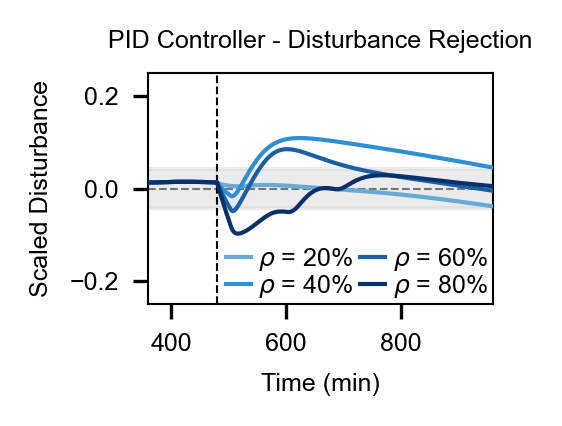

In [14]:
# %%
# Plot 1: PID error-from-setpoint responses
# Fully customizable styling for this plot

plot1_cfg = {
    'figsize': (1.75, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'line_width': 1,
    'axis_linewidth': 0.5,
    'zero_linewidth': 0.5,
    'tol_linewidth': 0.5,
    'perturb_linewidth': 0.5,
    'legend_loc': 'lower right',
    'tol_alpha': 0.5
}

plt.rcParams.update({
    'font.family': plot1_cfg['font_family'],
    'font.size': plot1_cfg['base_fontsize'],
    'axes.labelsize': plot1_cfg['label_fontsize'],
    'axes.titlesize': plot1_cfg['title_fontsize'],
    'legend.fontsize': plot1_cfg['legend_fontsize']
})

fig, ax = plt.subplots(figsize=plot1_cfg['figsize'], dpi=plot1_cfg['dpi'])

# Zero-error line and tolerance band
color_setpoint = '#d9d9d9'
ax.axhline(0.0, color='k', linestyle='--', linewidth=plot1_cfg['zero_linewidth'], alpha = 0.5)
ax.fill_between(
    [0, new_t_final_var],
    [-tol_band_norm, -tol_band_norm],
    [tol_band_norm, tol_band_norm],
    color=color_setpoint,
    alpha=plot1_cfg['tol_alpha']
)
# ax.axhline(+tol_band_norm, color=color_setpoint, linestyle='--', linewidth=plot1_cfg['tol_linewidth'])
# ax.axhline(-tol_band_norm, color=color_setpoint, linestyle='--', linewidth=plot1_cfg['tol_linewidth'])

# Disturbance marker
ax.axvline(perturb_time_var, color='black', linestyle='--', linewidth=plot1_cfg['perturb_linewidth'])

# Plot PID error responses
for pp in perturb_percents:
    ax.plot(
        pid_variation[pp]['t'],
        pid_variation[pp]['err'],
        linewidth=plot1_cfg['line_width'],
        color=disturbance_colors[pp],
        label=rf"$\rho$ = {pp}%",
        zorder=4
    )

ax.set_xlabel('Time (min)', fontsize=plot1_cfg['label_fontsize'])
ax.set_ylabel('Scaled Disturbance', fontsize=plot1_cfg['label_fontsize'])
ax.set_title(f'PID Controller - Disturbance Rejection', fontsize=plot1_cfg['title_fontsize'])
ax.set_xlim(0, new_t_final_var)

all_err = np.concatenate([pid_variation[pp]['err'] for pp in perturb_percents])
ymax = max(np.max(np.abs(all_err)), tol_band_norm) * 1.15
# ax.set_ylim(-ymax, ymax)
ax.set_ylim(-0.25, 0.25)
ax.set_xlim(360, time_extent)

ax.legend(frameon=False, loc=plot1_cfg['legend_loc'], fontsize=plot1_cfg['legend_fontsize'],
          ncol=2, columnspacing=0.3, labelspacing=0.01, handlelength=1, handletextpad=0.3,
          bbox_to_anchor=(1.05,-0.08))

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(plot1_cfg['axis_linewidth'])

ax.tick_params(axis='both', which='major', labelsize=plot1_cfg['tick_fontsize'])
plt.tight_layout()
#fig.set_facecolor('white')
#plt.savefig('figures/pid_perturbation_varying_percents.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)

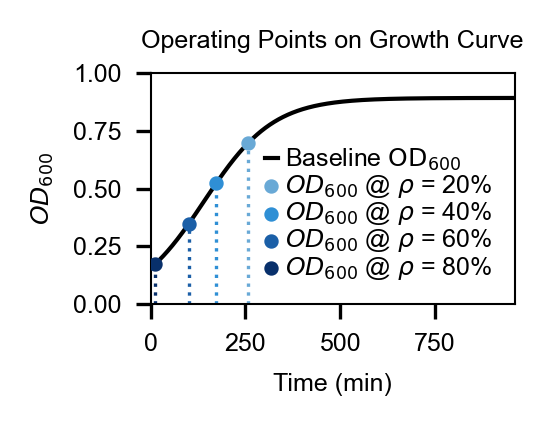

In [ ]:
# %%
# Plot 2: Baseline growth curve with annotated perturbation levels
# Fully customizable styling for this plot

plot2_cfg = {
    'figsize': (1.75, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'curve_linewidth': 1,
    'guide_linewidth': 0.8,
    'match_linewidth': 0.6,
    'drop_linewidth': 0.8,
    'perturb_linewidth': 0.8,
    'axis_linewidth': 0.5,
    'scatter_size_main': 6,
    'scatter_size_match': 6,
    'annotation_fontsize': 6,
    'legend_loc': 'lower right',
    'x_text_offset': 40
}

plt.rcParams.update({
    'font.family': plot2_cfg['font_family'],
    'font.size': plot2_cfg['base_fontsize'],
    'axes.labelsize': plot2_cfg['label_fontsize'],
    'axes.titlesize': plot2_cfg['title_fontsize'],
    'legend.fontsize': plot2_cfg['legend_fontsize']
})

time_growth_ref, _, sol_growth_ref = run_constant(
    t_final,
    x0_pid.copy(),
    params,
    constant_input='green',
    growth_perturb=0
)

growth_ref_od = sol_growth_ref[:, 9] / 8e8
od_pre = np.interp(perturb_time_var, time_growth_ref, growth_ref_od)

fig, ax = plt.subplots(figsize=plot2_cfg['figsize'], dpi=plot2_cfg['dpi'])

# Baseline growth curve
ax.plot(
    time_growth_ref,
    growth_ref_od,
    color='black',
    linewidth=plot2_cfg['curve_linewidth'],
    label=r'Baseline $\mathrm{OD}_{600}$'
)

# For monotonic growth, invert OD -> time using interpolation
baseline_time_from_od = lambda od_val: np.interp(od_val, growth_ref_od, time_growth_ref)

x_text = perturb_time_var + plot2_cfg['x_text_offset']

for pp in perturb_percents:
    od_post = od_pre * (1 - pp / 100.0)
    t_match = baseline_time_from_od(od_post)

    # Mark the corresponding point on the baseline curve
    ax.scatter(
        t_match,
        od_post,
        color=disturbance_colors[pp],
        s=plot2_cfg['scatter_size_match'],
        zorder=6,
        label=rf'$OD_{{600}}$ @ $\rho$ = {pp}%'
    )

    # Vertical line from x-axis to the matched point on the growth curve
    ax.vlines(
        t_match,
        0,
        od_post,
        colors=disturbance_colors[pp],
        linestyles=':',
        linewidth=plot2_cfg['guide_linewidth']
    )

ax.set_xlabel('Time (min)', fontsize=plot2_cfg['label_fontsize'])
ax.set_ylabel('$OD_{600}$', fontsize=plot2_cfg['label_fontsize'])
ax.set_title(r'Operating Points on Growth Curve', fontsize=plot2_cfg['title_fontsize'])
ax.set_xlim(0, new_t_final_var)
ax.set_ylim(0, 1)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(plot2_cfg['axis_linewidth'])

ax.tick_params(axis='both', which='major', labelsize=plot2_cfg['tick_fontsize'])
ax.legend(frameon=False, loc=plot2_cfg['legend_loc'], fontsize=plot2_cfg['legend_fontsize'],
          ncol=1, columnspacing=0.3, labelspacing=0.01, handlelength=0.5, handletextpad=0.3)
plt.tight_layout()
#plt.savefig('figures/operating_OD600.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)